# All-Hero Item Effectiveness — Volcano Plot

For every (upgrade item × opponent hero) pair, tests whether holding the item is associated with a higher win rate when facing that hero.

- **x-axis:** log₂(Odds Ratio)
- **y-axis:** −log₁₀(BH-adjusted p-value), correction applied globally across all hero×item pairs
- Shape encodes item slot: ○ weapon  □ vitality  △ spirit

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
RANK_MODE       = 'high'   # 'high' or 'low'
LOW_RANK_SAMPLE = 25_000   # reservoir size, only used when RANK_MODE == 'low'
RANDOM_SEED     = 42

MIN_N_WITH      = 20
MIN_N_WITHOUT   = 5
THRESH_P        = 0.05
THRESH_OR       = 1.2
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
import json, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_columns', None)
OTHER_TEAM = {'Team0': 'Team1', 'Team1': 'Team0'}

In [3]:
items_lookup  = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

upgrade_item_ids = set(items_lookup[items_lookup['type'] == 'upgrade']['id'])
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
item_slot        = items_lookup[items_lookup['type'] == 'upgrade'].set_index('name')['slot_type'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()

print(f'Upgrade items: {len(upgrade_item_ids)}  |  Heroes: {len(hero_id_to_name)}')

Upgrade items: 171  |  Heroes: 38


## Load match data

High-rank loads all qualifying matches. Low-rank uses reservoir sampling to stay manageable.

In [4]:
DATA_FILES = [f'data/collected_matches_recent_{RANK_MODE}.jsonl']

def iter_raw_matches():
    for path in DATA_FILES:
        if not os.path.exists(path):
            print(f'  {path} not found — skipping')
            continue
        print(f'  Scanning {path} ...')
        with open(path) as f:
            for line in f:
                try:
                    yield json.loads(line)
                except json.JSONDecodeError:
                    continue

if RANK_MODE == 'high':
    selected = list(iter_raw_matches())
else:
    # Reservoir sampling — O(1) memory growth beyond the reservoir
    rng = random.Random(RANDOM_SEED)
    reservoir, count = [], 0
    for match in iter_raw_matches():
        count += 1
        if len(reservoir) < LOW_RANK_SAMPLE:
            reservoir.append(match)
        else:
            j = rng.randint(0, count - 1)
            if j < LOW_RANK_SAMPLE:
                reservoir[j] = match
    selected = reservoir

print(f'Matches selected ({RANK_MODE} rank): {len(selected):,}')


  Scanning data/collected_matches_recent_high.jsonl ...
Matches selected (high rank): 25,000


In [5]:
player_rows, item_rows = [], []

for match in selected:
    mid = match['match_id']
    won = match['winning_team']
    for p in match['players']:
        team    = p['team']
        hero_id = np.int64(p['hero_id'])
        player_rows.append({'match_id': mid, 'team': team,
                            'hero_id': hero_id, 'won': int(team == won)})
        for item in p['items']:
            iid = np.uint32(item['item_id'])
            if iid not in upgrade_item_ids:
                continue
            item_rows.append({'match_id': mid, 'team': team,
                              'won': int(team == won), 'item_id': iid,
                              'held': item['sold_time_s'] == 0})

players_df = pd.DataFrame(player_rows)
items_df   = pd.DataFrame(item_rows)
items_df['item_name'] = items_df['item_id'].map(item_id_to_name)

print(f'Matches: {players_df["match_id"].nunique():,}')
print(f'Player rows: {len(players_df):,}  |  Item rows: {len(items_df):,}')

Matches: 25,000
Player rows: 300,000  |  Item rows: 4,956,457


## Chi-square tests — all (item × opponent hero) pairs

In [6]:
outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

# Wide table: one row per (match, team), columns = item held (0/1)
held_wide = (
    items_df[items_df['held']]
    .groupby(['match_id', 'team', 'item_name'])
    .size().gt(0).astype(int)
    .rename('held')
    .reset_index()
    .pivot_table(index=['match_id', 'team'], columns='item_name',
                 values='held', aggfunc='max', fill_value=0)
    .reset_index()
)
held_wide.columns.name = None
item_cols = [c for c in held_wide.columns if c not in ('match_id', 'team')]

base_df = outcomes.merge(held_wide, on=['match_id', 'team'], how='left')
base_df[item_cols] = base_df[item_cols].fillna(0).astype(int)

all_heroes = players_df['hero_id'].unique()
print(f'Heroes in dataset: {len(all_heroes)}  |  Items to test: {len(item_cols)}')

Heroes in dataset: 38  |  Items to test: 154


In [7]:
rows = []

for hero_id in all_heroes:
    hero_name = hero_id_to_name.get(np.int64(hero_id), str(hero_id))

    enemy_flag = (
        players_df[players_df['hero_id'] == hero_id][['match_id', 'team']]
        .assign(enemy=1)
        .assign(team=lambda d: d['team'].map(OTHER_TEAM))
    )
    team_df = base_df.merge(enemy_flag, on=['match_id', 'team'], how='left')
    team_df['enemy'] = team_df['enemy'].fillna(0).astype(int)

    facing = team_df[team_df['enemy'] == 1]
    n_facing = len(facing)

    for item in item_cols:
        with_item    = facing[facing[item] == 1]['won']
        without_item = facing[facing[item] == 0]['won']
        n1, n0 = len(with_item), len(without_item)
        if n1 < MIN_N_WITH or n0 < MIN_N_WITHOUT:
            continue

        a = int(with_item.sum())
        b = n1 - a
        c = int(without_item.sum())
        d = n0 - c
        if b == 0 or c == 0:
            continue

        chi2, p, _, _ = chi2_contingency(np.array([[a, b], [c, d]]), correction=False)
        or_val = (a * d) / (b * c)
        rows.append({
            'hero':       hero_name,
            'item':       item,
            'slot_type':  item_slot.get(item, 'unknown'),
            'n_facing':   n_facing,
            'n_with':     n1,
            'wr_with':    round(float(with_item.mean()), 3),
            'wr_without': round(float(without_item.mean()), 3),
            'wr_delta':   round(float(with_item.mean() - without_item.mean()), 3),
            'or':         or_val,
            'log2_or':    np.log2(or_val),
            'p_raw':      p,
        })

vdf = pd.DataFrame(rows)
print(f'Total (hero × item) pairs tested: {len(vdf):,}')

Total (hero × item) pairs tested: 5,851


In [8]:
# Global BH correction across all pairs
_, vdf['p_bh'], _, _ = multipletests(vdf['p_raw'], method='fdr_bh')
vdf['neg_log10_bh'] = -np.log10(vdf['p_bh'].clip(lower=1e-300))

log2_thresh = np.log2(THRESH_OR)

def categorise(row):
    if row['p_bh'] >= THRESH_P:
        return 'non-significant'
    if row['log2_or'] >  log2_thresh:
        return 'beneficial'
    if row['log2_or'] < -log2_thresh:
        return 'detrimental'
    return 'significant-small-effect'

vdf['category'] = vdf.apply(categorise, axis=1)
print('Category counts:')
print(vdf['category'].value_counts().to_string())

Category counts:
category
non-significant             2789
beneficial                  1848
significant-small-effect     736
detrimental                  478


## Volcano plot

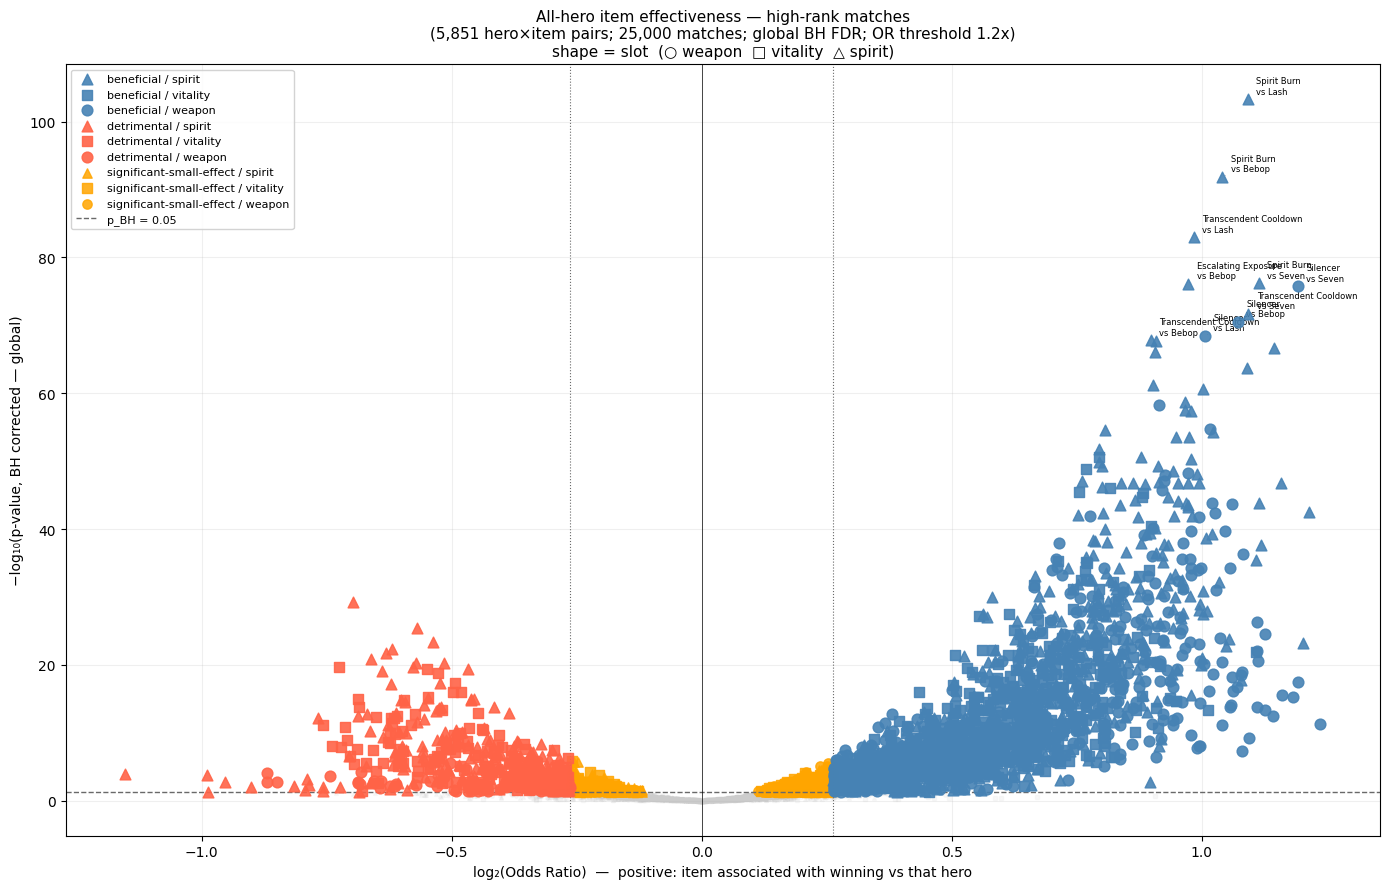

In [9]:
palette = {
    'beneficial':               'steelblue',
    'detrimental':              'tomato',
    'significant-small-effect': 'orange',
    'non-significant':          '#cccccc',
}
z_order      = {'non-significant': 1, 'significant-small-effect': 2, 'detrimental': 3, 'beneficial': 4}
sizes  = {'beneficial': 60, 'detrimental': 60, 'significant-small-effect': 45, 'non-significant': 7}
alphas = {'beneficial': 0.9, 'detrimental': 0.9, 'significant-small-effect': 0.85, 'non-significant': 0.12}
slot_markers = {'weapon': 'o', 'vitality': 's', 'spirit': '^', 'unknown': 'D'}

fig, ax = plt.subplots(figsize=(14, 9))

for cat, grp in vdf.groupby('category'):
    for slot, sgrp in grp.groupby('slot_type'):
        ax.scatter(sgrp['log2_or'], sgrp['neg_log10_bh'],
                   c=palette[cat], marker=slot_markers.get(slot, 'o'),
                   alpha=alphas[cat], s=sizes[cat], zorder=z_order.get(cat, 2),
                   label=f'{cat} / {slot}' if cat != 'non-significant' else None)

ax.axhline(-np.log10(THRESH_P), color='dimgrey', linestyle='--', linewidth=1,
           label=f'p_BH = {THRESH_P}')
ax.axvline( log2_thresh, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(-log2_thresh, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(0,            color='black',   linewidth=0.5)

# Label only top significant pairs by effect size
sig = vdf[vdf['category'].isin(['beneficial', 'detrimental'])].nlargest(10, 'neg_log10_bh')
for _, row in sig.iterrows():
    ax.annotate(
        f"{row['item']}\nvs {row['hero']}",
        xy=(row['log2_or'], row['neg_log10_bh']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=6, color='black',
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.4),
    )

n_pairs   = len(vdf)
n_matches = players_df['match_id'].nunique()
ax.set_xlabel('log₂(Odds Ratio)  —  positive: item associated with winning vs that hero', fontsize=10)
ax.set_ylabel('−log₁₀(p-value, BH corrected — global)', fontsize=10)
ax.set_title(
    f'All-hero item effectiveness — {RANK_MODE}-rank matches\n'
    f'({n_pairs:,} hero×item pairs; {n_matches:,} matches; global BH FDR; OR threshold {THRESH_OR}x)\n'
    f'shape = slot  (○ weapon  □ vitality  △ spirit)',
    fontsize=11,
)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(alpha=0.2)
plt.tight_layout()
os.makedirs(f'figures/recent_{RANK_MODE}', exist_ok=True)
plt.savefig(f'figures/recent_{RANK_MODE}/volcano_{RANK_MODE}_rank.png', dpi=150, bbox_inches='tight')
plt.show()

## Top significant pairs

In [10]:
sig_pairs = (
    vdf[vdf['category'] != 'non-significant']
    .sort_values('log2_or', ascending=False)
    [['hero', 'item', 'slot_type', 'n_with', 'wr_with', 'wr_without', 'wr_delta', 'or', 'p_bh', 'category']]
    .rename(columns={'wr_delta': 'ΔWR', 'or': 'OR', 'p_bh': 'p (BH)', 'n_with': 'n held'})
    .reset_index(drop=True)
)
display(sig_pairs.round(3))

,hero,item,slot_type,n held,wr_with,wr_without,ΔWR,OR,p (BH),category
0,Mirage,Frenzy,weapon,331,0.689,0.484,0.204,2.357,0.000,beneficial
1,Apollo,Boundless Spirit,spirit,5974,0.535,0.332,0.204,2.321,0.000,beneficial
2,McGinnis,Boundless Spirit,spirit,3863,0.465,0.274,0.191,2.302,0.000,beneficial
3,Apollo,Frenzy,weapon,553,0.678,0.480,0.199,2.286,0.000,beneficial
4,Seven,Silencer,weapon,3011,0.585,0.382,0.204,2.286,0.000,beneficial
...,...,...,...,...,...,...,...,...,...,...
3057,Celeste,Mystic Regeneration,spirit,89,0.360,0.512,-0.152,0.535,0.010,detrimental
3058,Ivy,Mystic Regeneration,spirit,120,0.317,0.473,-0.156,0.517,0.002,detrimental
3059,Viscous,Golden Goose Egg,spirit,45,0.356,0.522,-0.167,0.504,0.049,detrimental
3060,Rem,Rusted Barrel,spirit,146,0.384,0.553,-0.169,0.504,0.000,detrimental
